<a href="https://colab.research.google.com/github/Antonyus1204/BIOESTADISTICA2/blob/main/BIO218_Repaso_Parcial1_Completo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# UNIVERSIDAD DE PANAMÁ
## Centro Regional Universitario de Veraguas
### Facultad de Ciencias Naturales, Exactas y Tecnologías
### Escuela de Biología

**Asignatura:** BIO 218 - Biología Cuantitativa  
**Taller de repaso:** Preparación para el Primer Parcial Teórico–Práctico  
**Profesora:** Dra. Nena Robles Rodríguez  
**Segundo semestre:** 2026  
**Entorno:** Google Colab  
**Dataset:** `BIO218_Repaso_Parcial1_datos.csv`

---

## Propósito
Este notebook integra los contenidos evaluados en el **Primer Parcial**: Biología Cuantitativa; investigación y variables; fundamentos de Python/Pandas; estadística descriptiva; probabilidad; inferencia estadística; selección e interpretación de pruebas.

**Ruta de razonamiento:** pregunta biológica → variables → importación → exploración → control de calidad → descripción → visualización → supuestos → prueba → interpretación.

## 1. Fundamentos conceptuales que debes dominar

### Biología Cuantitativa
Integra medición, estadística, programación e interpretación biológica.

### Investigación científica
- **Pregunta:** específica y medible.
- **Hipótesis:** relación/diferencia contrastable.
- **Población:** conjunto total de interés.
- **Muestra:** subconjunto observado.
- **Unidad experimental:** unidad independiente que recibe una condición.

### Tipos de variables
- Cualitativas: nominales u ordinales.
- Cuantitativas: discretas o continuas.
- Escalas: nominal, ordinal, intervalo y razón.

## 2. Diccionario del dataset de práctica

| Variable | Tipo |
|---|---|
| `id_planta` | Identificador |
| `grupo` | Cualitativa nominal |
| `longitud_cm` | Cuantitativa continua |
| `biomasa_g` | Cuantitativa continua |
| `clorofila_SPAD` | Cuantitativa continua |
| `lesiones_count` | Cuantitativa discreta |
| `germino` | Dicotómica/binaria |
| `tiempo_respuesta_min` | Cuantitativa continua, positiva y asimétrica |

**Unidad experimental:** cada plántula.

In [64]:
# ============================================================
# CELDA 1. LIBRERÍAS
# ============================================================
# Pandas: importación y manipulación de datos tabulares.
import pandas as pd

# NumPy: operaciones numéricas, arrays y simulaciones.
import numpy as np

# SciPy.stats: distribuciones y pruebas estadísticas.
from scipy import stats

# Matplotlib: visualización científica.
import matplotlib.pyplot as plt

# Seaborn: visualización estadística.
import seaborn as sns

# Statsmodels: ANOVA y modelación estadística.
import statsmodels.api as sm
from statsmodels.formula.api import ols

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
print("Entorno preparado correctamente.")

Entorno preparado correctamente.


## 3. Repaso de Python básico
Una variable de Python almacena un objeto; no es lo mismo que una variable estadística.

In [65]:
# ============================================================
# CELDA 2. TIPOS DE DATOS, LISTAS Y ARRAYS
# ============================================================
numero_plantas = 12          # int
longitud_media = 12.4        # float
grupo = "Control"            # str
germino = True               # bool

lista_longitudes = [11.8, 12.1, 12.4, 11.9]
array_longitudes = np.array(lista_longitudes)

print(type(numero_plantas), type(longitud_media), type(grupo), type(germino))
print("Media del array:", array_longitudes.mean())

<class 'int'> <class 'float'> <class 'str'> <class 'bool'>
Media del array: 12.049999999999999


In [67]:
# ============================================================
# CELDA 3. FUNCIÓN SENCILLA
# ============================================================
def calcular_rango(valores):
    # Rango = valor máximo - valor mínimo.
    return max(valores) - min(valores)

print("Rango:", calcular_rango(lista_longitudes))

Rango: 0.5999999999999996


## 4. Carga del CSV en Google Colab
1. Sube el CSV al panel izquierdo **Archivos**.
2. Verifica que esté en `/content/`.
3. Cárgalo con `pd.read_csv()`.

In [68]:
# ============================================================
# CELDA 4. CARGA DIRECTA CON pd.read_csv()
# ============================================================
ruta_archivo = "/content/BIO218_Repaso_Parcial1_datos.csv"
df = pd.read_csv(ruta_archivo)

print("Base cargada correctamente.")
print("Dimensiones:", df.shape)
df.head()

Base cargada correctamente.
Dimensiones: (37, 8)


,id_planta,grupo,longitud_cm,biomasa_g,clorofila_SPAD,lesiones_count,germino,tiempo_respuesta_min
0,P01,Control,12.55,1.41,32.9,3,1,6.84
1,P02,Control,11.28,1.71,28.3,4,0,7.45
2,P03,Control,11.98,1.19,29.6,3,1,8.40
3,P04,Control,12.10,1.65,33.7,7,1,7.79
4,P05,Control,11.35,1.73,33.4,5,1,10.75


In [69]:
# ============================================================
# CELDA 5. head(), info() y describe()
# ============================================================
display(df.head())
df.info()
display(df.describe())

,id_planta,grupo,longitud_cm,biomasa_g,clorofila_SPAD,lesiones_count,germino,tiempo_respuesta_min
0,P01,Control,12.55,1.41,32.9,3,1,6.84
1,P02,Control,11.28,1.71,28.3,4,0,7.45
2,P03,Control,11.98,1.19,29.6,3,1,8.40
3,P04,Control,12.10,1.65,33.7,7,1,7.79
4,P05,Control,11.35,1.73,33.4,5,1,10.75


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37 entries, 0 to 36
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id_planta             37 non-null     object 
 1   grupo                 37 non-null     object 
 2   longitud_cm           37 non-null     float64
 3   biomasa_g             36 non-null     float64
 4   clorofila_SPAD        37 non-null     float64
 5   lesiones_count        37 non-null     int64  
 6   germino               37 non-null     int64  
 7   tiempo_respuesta_min  37 non-null     float64
dtypes: float64(4), int64(2), object(2)
memory usage: 2.4+ KB


,longitud_cm,biomasa_g,clorofila_SPAD,lesiones_count,germino,tiempo_respuesta_min
count,37.000000,36.000000,37.000000,37.000000,37.000000,37.000000
mean,12.258649,1.702778,33.272973,3.351351,0.837838,8.594054
std,0.890010,0.238850,3.283853,1.767236,0.373684,2.960814
min,10.790000,1.190000,28.300000,0.000000,0.000000,3.360000
25%,11.700000,1.537500,31.500000,2.000000,1.000000,5.820000
50%,12.140000,1.725000,32.900000,3.000000,1.000000,9.050000
75%,12.780000,1.825000,34.000000,4.000000,1.000000,10.750000
max,14.260000,2.170000,46.500000,8.000000,1.000000,13.750000


# BLOQUE I. CONTROL DE CALIDAD Y EDA
Antes de inferir: revisar estructura, ausentes, duplicados y valores potencialmente atípicos.

In [70]:
# ============================================================
# CELDA 6. DATOS AUSENTES
# ============================================================
print("Ausentes por variable:")
print(df.isna().sum())

print("\nPorcentaje de ausencia:")
print((df.isna().mean()*100).round(2))

Ausentes por variable:
id_planta               0
grupo                   0
longitud_cm             0
biomasa_g               1
clorofila_SPAD          0
lesiones_count          0
germino                 0
tiempo_respuesta_min    0
dtype: int64

Porcentaje de ausencia:
id_planta               0.0
grupo                   0.0
longitud_cm             0.0
biomasa_g               2.7
clorofila_SPAD          0.0
lesiones_count          0.0
germino                 0.0
tiempo_respuesta_min    0.0
dtype: float64


In [71]:
# ============================================================
# CELDA 7. DUPLICADOS
# ============================================================
print("Duplicados exactos:", df.duplicated().sum())
display(df[df.duplicated(keep=False)])

Duplicados exactos: 1


,id_planta,grupo,longitud_cm,biomasa_g,clorofila_SPAD,lesiones_count,germino,tiempo_respuesta_min
7,P08,Control,10.79,1.35,31.8,3,1,9.35
36,P08,Control,10.79,1.35,31.8,3,1,9.35


In [72]:
# ============================================================
# CELDA 8. COPIA DE TRABAJO Y LIMPIEZA
# ============================================================
# Conservamos el DataFrame original.
df_limpio = df.copy()

# Eliminamos únicamente duplicados exactos.
df_limpio = df_limpio.drop_duplicates().reset_index(drop=True)

print("Nueva dimensión:", df_limpio.shape)

Nueva dimensión: (36, 8)


## 5. Imputación simple con fines docentes
El valor ausente de `biomasa_g` se imputará con la **mediana del grupo experimental**. Es una estrategia introductoria, no una regla universal.

In [73]:
# ============================================================
# CELDA 9. IMPUTACIÓN POR MEDIANA DEL GRUPO
# ============================================================
mediana_grupo = df_limpio.groupby("grupo")["biomasa_g"].transform("median")
df_limpio["biomasa_g"] = df_limpio["biomasa_g"].fillna(mediana_grupo)
print("Ausentes restantes en biomasa_g:", df_limpio["biomasa_g"].isna().sum())

Ausentes restantes en biomasa_g: 0


## 6. Valores atípicos por IQR
`IQR = Q3 - Q1`. Un valor fuera de `Q1 - 1.5·IQR` o `Q3 + 1.5·IQR` se marca para revisión; **no se elimina automáticamente**.

In [74]:
# ============================================================
# CELDA 10. OUTLIERS MEDIANTE IQR
# ============================================================
x = df_limpio["clorofila_SPAD"]
q1 = x.quantile(0.25)
q3 = x.quantile(0.75)
iqr = q3 - q1
li = q1 - 1.5*iqr
ls = q3 + 1.5*iqr
mascara = (x < li) | (x > ls)

print("Q1:", round(q1,2), "Q3:", round(q3,2), "IQR:", round(iqr,2))
print("Límites:", round(li,2), round(ls,2))
display(df_limpio.loc[mascara])

Q1: 31.45 Q3: 34.08 IQR: 2.63
Límites: 27.51 38.01


,id_planta,grupo,longitud_cm,biomasa_g,clorofila_SPAD,lesiones_count,germino,tiempo_respuesta_min
13,P14,Tratamiento_A,13.53,1.84,39.4,1,0,3.36
20,P21,Tratamiento_A,13.57,1.94,46.5,0,1,5.53


# BLOQUE II. ESTADÍSTICA DESCRIPTIVA
Debes dominar media, mediana, moda, rango, varianza, desviación estándar e IQR.

In [75]:
# ============================================================
# CELDA 11. MEDIDAS DESCRIPTIVAS
# ============================================================
longitud = df_limpio["longitud_cm"]

print("Media:", round(longitud.mean(),3))
print("Mediana:", round(longitud.median(),3))
print("Moda:", longitud.mode().tolist())
print("Rango:", round(longitud.max()-longitud.min(),3))
print("Varianza muestral:", round(longitud.var(ddof=1),3))
print("DE muestral:", round(longitud.std(ddof=1),3))
print("IQR:", round(longitud.quantile(.75)-longitud.quantile(.25),3))

Media: 12.299
Mediana: 12.145
Moda: [11.48]
Rango: 3.47
Varianza muestral: 0.751
DE muestral: 0.867
IQR: 1.092


In [ ]:
# ============================================================
# CELDA 12. groupby() POR GRUPO EXPERIMENTAL
# ============================================================
resumen = (
    df_limpio.groupby("grupo")["longitud_cm"]
    .agg(["count","mean","median","std","min","max"])
    .round(2)
)
display(resumen)

,count,mean,median,std,min,max
grupo,,,,,,
Control,12,11.58,11.57,0.53,10.79,12.55
Tratamiento_A,12,13.08,13.43,0.80,11.71,14.26
Tratamiento_B,12,12.23,12.16,0.49,11.48,13.16


# BLOQUE III. VISUALIZACIÓN
- Histograma: forma de una variable cuantitativa.
- Boxplot: centro, dispersión y valores extremos.
- Scatterplot: relación entre dos variables cuantitativas.
- Violin plot: forma de la distribución por grupo.

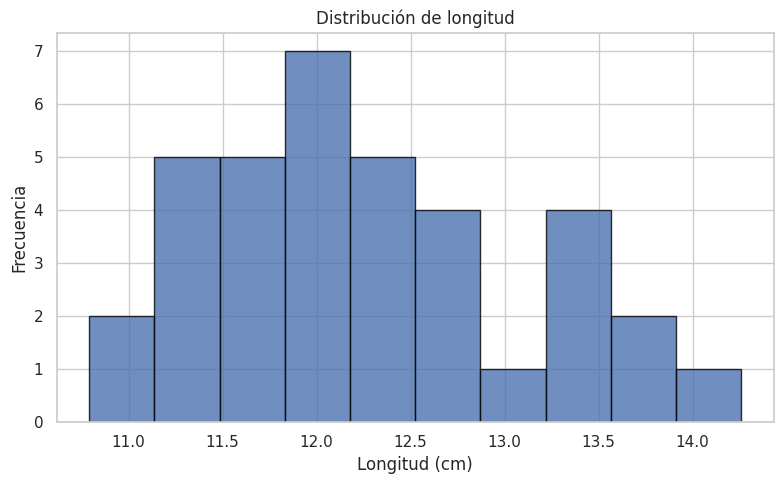

In [76]:
# ============================================================
# CELDA 13. HISTOGRAMA
# ============================================================
plt.figure(figsize=(8,5))
plt.hist(df_limpio["longitud_cm"], bins=10, edgecolor="black", alpha=.8)
plt.title("Distribución de longitud")
plt.xlabel("Longitud (cm)")
plt.ylabel("Frecuencia")
plt.tight_layout(); plt.show()

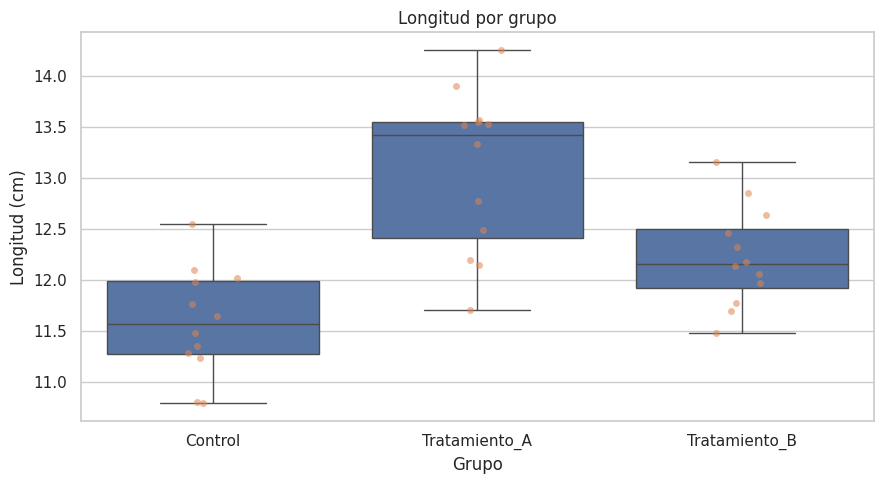

In [77]:
# ============================================================
# CELDA 14. BOXPLOT
# ============================================================
plt.figure(figsize=(9,5))
sns.boxplot(data=df_limpio, x="grupo", y="longitud_cm")
sns.stripplot(data=df_limpio, x="grupo", y="longitud_cm", alpha=.55)
plt.title("Longitud por grupo")
plt.xlabel("Grupo"); plt.ylabel("Longitud (cm)")
plt.tight_layout(); plt.show()

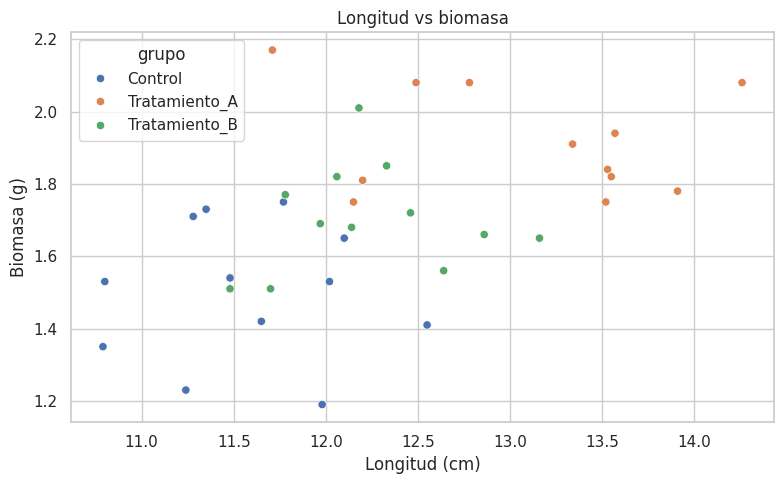

In [78]:
# ============================================================
# CELDA 15. SCATTERPLOT
# ============================================================
plt.figure(figsize=(8,5))
sns.scatterplot(data=df_limpio, x="longitud_cm", y="biomasa_g", hue="grupo")
plt.title("Longitud vs biomasa")
plt.xlabel("Longitud (cm)"); plt.ylabel("Biomasa (g)")
plt.tight_layout(); plt.show()

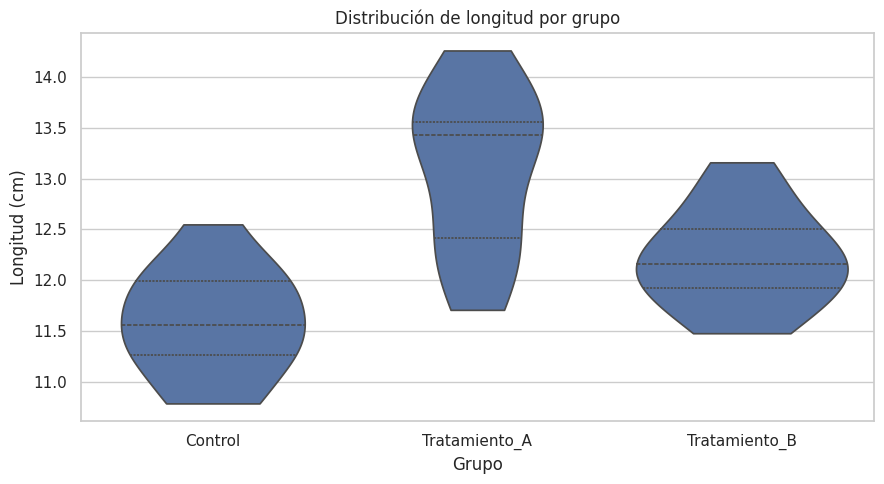

In [79]:
# ============================================================
# CELDA 16. VIOLIN PLOT
# ============================================================
plt.figure(figsize=(9,5))
sns.violinplot(data=df_limpio, x="grupo", y="longitud_cm", inner="quartile", cut=0)
plt.title("Distribución de longitud por grupo")
plt.xlabel("Grupo"); plt.ylabel("Longitud (cm)")
plt.tight_layout(); plt.show()

# BLOQUE IV. PROBABILIDAD Y DISTRIBUCIONES

### Probabilidad simple
`P(A) = favorables / total`.

### Probabilidad condicional
`P(A|B)` = probabilidad de A entre quienes cumplen B.

### Distribuciones
- Normal: variable continua aproximadamente simétrica.
- Binomial: número de éxitos en `n` ensayos dicotómicos.
- Poisson: conteo de eventos por unidad.

In [80]:
# ============================================================
# CELDA 17. PROBABILIDAD SIMPLE Y CONDICIONAL
# ============================================================
print("P(germinar) =", round(df_limpio["germino"].mean(),3))

A = df_limpio[df_limpio["grupo"]=="Tratamiento_A"]
print("P(germinar | Tratamiento_A) =", round(A["germino"].mean(),3))

P(germinar) = 0.833
P(germinar | Tratamiento_A) = 0.75


In [83]:
# ============================================================
# CELDA 18. NORMAL, BINOMIAL Y POISSON
# ============================================================
rng = np.random.default_rng(218)

sim_normal = rng.normal(loc=12, scale=1.5, size=500)
sim_binomial = rng.binomial(n=20, p=.70, size=100)
sim_poisson = rng.poisson(lam=3, size=150)

print("Media normal simulada:", round(sim_normal.mean(),2))
print("Media binomial simulada:", round(sim_binomial.mean(),2))
print("Media Poisson simulada:", round(sim_poisson.mean(),2))

Media normal simulada: 11.83
Media binomial simulada: 14.16
Media Poisson simulada: 3.11


## 7. Variabilidad muestral
Si repetimos el muestreo, las medias cambian. Al aumentar `n`, la distribución de medias suele ser menos variable.

In [84]:
# ============================================================
# CELDA 19. DISTRIBUCIÓN MUESTRAL
# ============================================================
poblacion = rng.normal(loc=12, scale=1.5, size=10000)
medias_n5=[]; medias_n30=[]

for _ in range(500):
    medias_n5.append(rng.choice(poblacion,5,replace=False).mean())
    medias_n30.append(rng.choice(poblacion,30,replace=False).mean())

medias_n5=np.array(medias_n5)
medias_n30=np.array(medias_n30)

print("DE de medias con n=5:", round(medias_n5.std(ddof=1),3))
print("DE de medias con n=30:", round(medias_n30.std(ddof=1),3))

DE de medias con n=5: 0.684
DE de medias con n=30: 0.284


# BLOQUE V. INFERENCIA ESTADÍSTICA

Ejemplo: **¿Tratamiento_A modifica la longitud respecto al Control?**

- H₀: medias iguales.
- H₁: medias diferentes.
- α = 0.05.

Regla operativa:
- `p ≤ α`: rechazar H₀.
- `p > α`: no rechazar H₀.

**El p-valor no es la probabilidad de que H₀ sea verdadera.**

In [85]:
# ============================================================
# CELDA 20. PREPARACIÓN DE GRUPOS
# ============================================================
x_control = df_limpio.loc[df_limpio["grupo"]=="Control","longitud_cm"]
x_A = df_limpio.loc[df_limpio["grupo"]=="Tratamiento_A","longitud_cm"]
x_B = df_limpio.loc[df_limpio["grupo"]=="Tratamiento_B","longitud_cm"]

## 8. Supuestos
- Independencia: se justifica por diseño.
- Normalidad: Shapiro–Wilk + gráficos.
- Homogeneidad de varianzas: Levene.

In [86]:
# ============================================================
# CELDA 21. SHAPIRO-WILK
# ============================================================
for nombre,valores in {"Control":x_control,"Tratamiento_A":x_A,"Tratamiento_B":x_B}.items():
    W,p = stats.shapiro(valores)
    print(f"{nombre}: W={W:.4f}, p={p:.4f}")

Control: W=0.9678, p=0.8862
Tratamiento_A: W=0.9312, p=0.3926
Tratamiento_B: W=0.9812, p=0.9878


In [87]:
# ============================================================
# CELDA 22. LEVENE
# ============================================================
L,pL = stats.levene(x_control,x_A,x_B)
print("Levene:", round(L,4), "p=", round(pL,4))

Levene: 1.4268 p= 0.2545


## 9. Comparación de dos grupos
- t de Student: dos grupos independientes, variable cuantitativa y supuestos razonables.
- Mann–Whitney: alternativa basada en rangos cuando un método no paramétrico es más apropiado.

In [88]:
# ============================================================
# CELDA 23. t DE STUDENT
# ============================================================
t_stat,p_t = stats.ttest_ind(x_control,x_A,equal_var=True,alternative="two-sided")
print("t =", round(t_stat,4))
print("p =", format(p_t,'.6g'))
print("Decisión:", "rechazar H0" if p_t<=.05 else "no rechazar H0")

t = -5.4317
p = 1.86477e-05
Decisión: rechazar H0


In [89]:
# ============================================================
# CELDA 24. DIFERENCIA DE MEDIAS, IC95% Y COHEN d
# ============================================================
media_c=x_control.mean(); media_a=x_A.mean(); dif=media_c-media_a
n1=len(x_control); n2=len(x_A)
s1_2=x_control.var(ddof=1); s2_2=x_A.var(ddof=1)
var_pooled=(((n1-1)*s1_2)+((n2-1)*s2_2))/(n1+n2-2)
sd_pooled=np.sqrt(var_pooled)
se=np.sqrt(var_pooled*(1/n1+1/n2))
gl=n1+n2-2
tcrit=stats.t.ppf(.975,gl)
li=dif-tcrit*se; ls=dif+tcrit*se
cohen_d=dif/sd_pooled

print("Diferencia Control - A:", round(dif,3))
print("IC95%:", (round(li,3),round(ls,3)))
print("Cohen d:", round(cohen_d,3))

Diferencia Control - A: -1.5
IC95%: (np.float64(-2.073), np.float64(-0.927))
Cohen d: -2.217


In [90]:
# ============================================================
# CELDA 25. MANN-WHITNEY
# ============================================================
tiempo_c=df_limpio.loc[df_limpio["grupo"]=="Control","tiempo_respuesta_min"]
tiempo_a=df_limpio.loc[df_limpio["grupo"]=="Tratamiento_A","tiempo_respuesta_min"]
U,p_mw=stats.mannwhitneyu(tiempo_c,tiempo_a,alternative="two-sided")
print("Mediana Control:", round(tiempo_c.median(),2))
print("Mediana A:", round(tiempo_a.median(),2))
print("U =", U, "p =", format(p_mw,'.6g'))

Mediana Control: 9.55
Mediana A: 6.11
U = 95.0 p = 0.193931


## 10. Comparación de tres grupos
- ANOVA: compara medias globalmente si los supuestos son razonables.
- Kruskal–Wallis: alternativa basada en rangos para ≥3 grupos independientes.

Un resultado global significativo indica evidencia de diferencia global, no que todos los grupos sean distintos.

In [91]:
# ============================================================
# CELDA 26. ANOVA DE UNA VÍA
# ============================================================
modelo=ols("longitud_cm ~ C(grupo)",data=df_limpio).fit()
tabla_anova=sm.stats.anova_lm(modelo,typ=2)
display(tabla_anova)

,sum_sq,df,F,PR(>F)
C(grupo),13.586806,2.0,17.634676,0.000006
Residual,12.712583,33.0,NaN,NaN


In [92]:
# ============================================================
# CELDA 27. ETA CUADRADO
# ============================================================
ss_grupo=tabla_anova.loc["C(grupo)","sum_sq"]
ss_total=tabla_anova["sum_sq"].sum()
eta2=ss_grupo/ss_total
print("Eta cuadrado =", round(eta2,3))

Eta cuadrado = 0.517


In [93]:
# ============================================================
# CELDA 28. KRUSKAL-WALLIS
# ============================================================
tiempo_b=df_limpio.loc[df_limpio["grupo"]=="Tratamiento_B","tiempo_respuesta_min"]
H,p_kw=stats.kruskal(tiempo_c,tiempo_a,tiempo_b)
print("H =", round(H,4))
print("p =", format(p_kw,'.6g'))

H = 2.018
p = 0.36458


# BLOQUE VI. ALGORITMO DE SELECCIÓN DE PRUEBA

### Dos grupos independientes
- Cuantitativa + supuestos razonables → **t de Student**.
- No paramétrica/ordinal/rangos → **Mann–Whitney**.

### Tres o más grupos independientes
- Cuantitativa + supuestos razonables → **ANOVA**.
- No paramétrica/ordinal/rangos → **Kruskal–Wallis**.

### Secuencia correcta
**Pregunta → diseño → variable → grupos → supuestos → prueba → efecto → interpretación.**

# BLOQUE VII. MINI-SIMULACRO

## Caso integrado
Se desea evaluar si tres tratamientos modifican la longitud de plántulas.

1. ¿Variable dependiente?  
2. ¿Variable independiente?  
3. ¿Tipo de variable de `longitud_cm`?  
4. ¿Unidad experimental?  
5. Formule H₀ y H₁.  
6. ¿Qué supuestos debe revisar?  
7. ¿Qué prueba usaría con supuestos paramétricos razonables?  
8. ¿Qué alternativa no paramétrica corresponde?  
9. ¿Qué significa `p = 0.03`?  
10. ¿Por qué reportar tamaño del efecto?

## Respuestas razonadas
1. `longitud_cm`.  
2. `grupo`.  
3. Cuantitativa continua.  
4. Cada plántula independiente.  
5. H₀: medias iguales; H₁: al menos una difiere.  
6. Independencia, normalidad y homogeneidad.  
7. ANOVA de una vía.  
8. Kruskal–Wallis.  
9. Los datos serían poco compatibles con H₀ bajo el modelo/supuestos; no significa que H₀ tenga 3 % de probabilidad de ser verdadera.  
10. Porque el p-valor no cuantifica la magnitud biológica.

## Checklist final para el parcial
- [ ] `pd.read_csv()`
- [ ] `head()`, `info()`, `describe()`
- [ ] tipos de variables y escalas
- [ ] ausentes, duplicados y outliers
- [ ] media, mediana, moda, rango, varianza, DE, IQR
- [ ] histograma, boxplot, scatterplot, violin plot
- [ ] probabilidad simple y condicional
- [ ] normal, binomial y Poisson
- [ ] variabilidad muestral
- [ ] H₀, H₁, α, p-valor, IC y tamaño del efecto
- [ ] Shapiro–Wilk y Levene
- [ ] t, Mann–Whitney, ANOVA y Kruskal–Wallis
- [ ] interpretación biológica prudente

---
**Universidad de Panamá · BIO 218 · Biología Cuantitativa**  
**Profesora: Dra. Nena Robles Rodríguez**